### **3.1 Time Series Data Preprocessing**

In this activity we will focus on preparing your time series data for forecasting models. We will be using the same libraries in Python that you've used in your predictive analytics and machine learning courses.

This is a code along exercise so that you get used to some basic data preprocessing for time series. This is in addition to what you've learned previously in your other courses.

The following are the Python SciPy libraries that we are using:
- NumPy
- Matplotlib
- Pandas

The goal of this activity is for you to learn:
- how to plot time series data
- how to decompose the time series data
- how to apply transformations

**Data Description**

We will be using the data that we discussed in the content videos (JohnsonAndJohnson.csv). The data contains Johnson and Johnson quarterly earnings from 1960-1980.

Attributes:
- time (YYY-MM) year and the quarterly month
- JohnsonJohnson is a float value that represents the earnings per share (EPS)

#### Part 1 - Data Preparation and Distribution Analysis

**Step 1.1 Import Libraries**

In [13]:
# Install required packages if not already installed
# python -m pip install pandas numpy matplotlib
# python -m pip install --upgrade pip
# python -m pip install ipykernel
# python -m pip install scipy

#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy.stats import boxcox
from scipy.stats import normaltest
from scipy.optimize import minimize

**Step 1.2 Import Data**

In this step, please upload the `JohnsonAndJohnson.csv` and `JohnsonAndJohnsonCompetitor.csv` files.

In [2]:
df = pd.read_csv(".\\data\\JohnsonAndJohnson_4.csv")
df.head()

,time,JohnsonJohnson
0,1/1/1960,0.71
1,1/4/1960,0.63
2,2/7/1960,0.85
3,1/10/1960,0.44
4,1/1/1961,0.61


**Step 1.3 Check if the month is a time series object**

We can see that **JohnsonJohnson** attribute is float. **time** is stored as a str object for now.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            84 non-null     str    
 1   JohnsonJohnson  84 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.4 KB


**Step 1.4 Convert Month into DateTime format**

We can see that the format of our date is Day?Month/Year. By default, the `pandas.to_time` method assumes Year/Month/Day, so we use the parameter `dayfirst = True` for a correct conversion.

In [4]:
df["time"] = pd.to_datetime(df["time"], dayfirst=True)

In [5]:
# we will make time the index so that we can filter data
# by year, month, days, weekend, specific range etc...
df = df.set_index("time")
# ensure the time series is in correct chronological order
df = df.sort_index()
df.head()

,JohnsonJohnson
time,
1960-01-01,0.71
1960-04-01,0.63
1960-07-02,0.85
1960-10-01,0.44
1961-01-01,0.61


In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 84 entries, 1960-01-01 to 1980-10-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   JohnsonJohnson  84 non-null     float64
dtypes: float64(1)
memory usage: 1.3 KB


**Step 1.5 Check Distribution of Original Data**

**What Are We Looking For?**

**1. Skewness**

If the data is heavily skewed (e.g., values are mostly low but but with some high outliers), it may affect model accuracy and forecast reliability.

While **skewness in the raw data doesn't break time series models directly**, skewness in the raw data may indicate:

- The presence of outliers or rare extreme values.

- That the **variance increases with the level of the series** (i.e. multiplicative behaviour).

- That the data may not be suitable for models assuming a symmetric or stable distribution.

**2. Variance Stability**

If the variability in the data increases over time (larger values are more volatile), this indicates non-constant variance. Many forecasting models assume constant variance (homoscedasticity).

**3. Need for Transformation**

If we see skewed data or increasing spread, it may be appropriate to apply a transformation such as Box-Cox. This can help:

- Stabilise variance

- Make the data more symmetric

- Improve model performance and the reliability of forecast intervals.

**How Do We Check?**

We inspect the distribution of the original series using a histogram. If necessary, we apply the Box-Cox transformation and compare the result. A well-shaped distribution is more suitable for modelling.

**Why It Matters for Forecasting**

If the data shows increasing spread (i.e. variance grows with the level of the series), it may be appropriate to apply a transformation - such as the Box-Cox transformation.

Transformations can help to:

- Stabilise variance across time

- Improve model assumptions (e.g. residuals that are normally distributed and homoscedastic)

- Support more reliable forecast intervals and inference

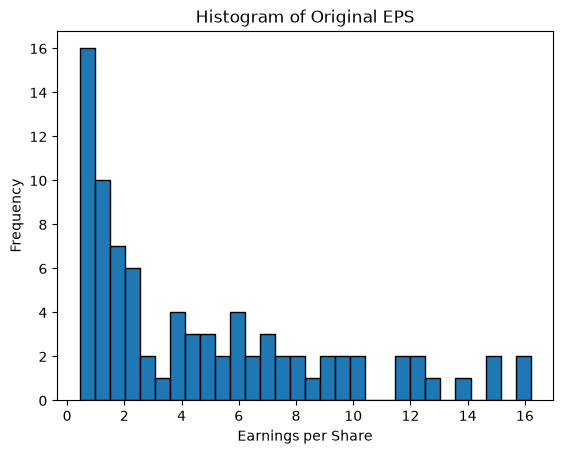

In [7]:
plt.hist(df["JohnsonJohnson"], bins=30, edgecolor='black')
plt.xlabel("Earnings per Share")
plt.ylabel("Frequency")
plt.title("Histogram of Original EPS")
plt.show()

**Step 1.6 Apply Box-Cox Transformation (requires strictly positive data)**

From the distribution plot, we can see that the data is skewed. Let's not plot the original time series to visually assess whether the variance appears to be constant over time.

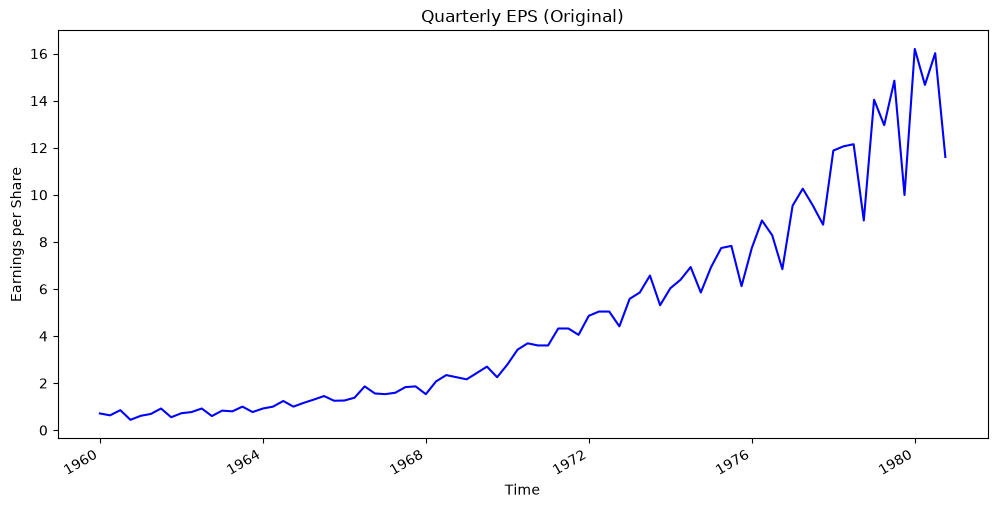

In [8]:
# Visualise Original Time Series

df["JohnsonJohnson"].plot(figsize=(12, 6), title="Quarterly EPS (Original)", color='blue')
plt.xlabel("Time")
plt.ylabel("Earnings per Share")
plt.show()

As you can see from the time series plot, **the variance does not appear to be constant** - it increases over time. This pattern suggests that a **variance-stabilising transformation, such as Box-Cox**, may be appropriate before modelling.

**What is the Box-Cox Transformation?**

The Box-Cox transformation is a mathematical technique used to **stabilise the variance** and make a time series more symmetric (closer to a normal distribution). It is particularly useful when the variability in a series increases with its level, which can negatively affect model performance.

This transformation is defined as:

- If $\lambda\ne0:$

$$y^{(\lambda)}=\frac{y^\lambda-1}{\lambda}$$

- If $\lambda=0:$

$$y^{(\lambda)}=\ln(y)$$

The transformation is applied to the raw (positive-only) data, and the optimal $\lambda$ is chosen automatically to best normalise the data and stabilise its variance.

**Why Use It?**

- To reduce skewness in the data

- To stabilise increasing or decreasing variance over time

- To improve the assumptions of classical forecasting models (e.g., ARIMA), which often expect constant variance and normally distributed residuals.

>> **Note:** The Box-Cox transformation **only works with strictly positive values**. If your series contains zeros or negative values, an alternative like the Yeo-Johnson transformation is required.

In [9]:
# apply box-cox transformation to the data to stabilise variance and make it more normally distributed
# in logarithmic or power transform, there is lambda parameter
# we will use the boxcox function with the default
# parameter value for "lmbda", which is "None"
# "None" value will find the optimal lambda value.
ext, lmbda = boxcox(df["JohnsonJohnson"])
xts = pd.Series(ext, index=df.index)

print(f"Optimal lambda value for Box-Cox transformation: {lmbda:.4f}")

Optimal lambda value for Box-Cox transformation: 0.0507


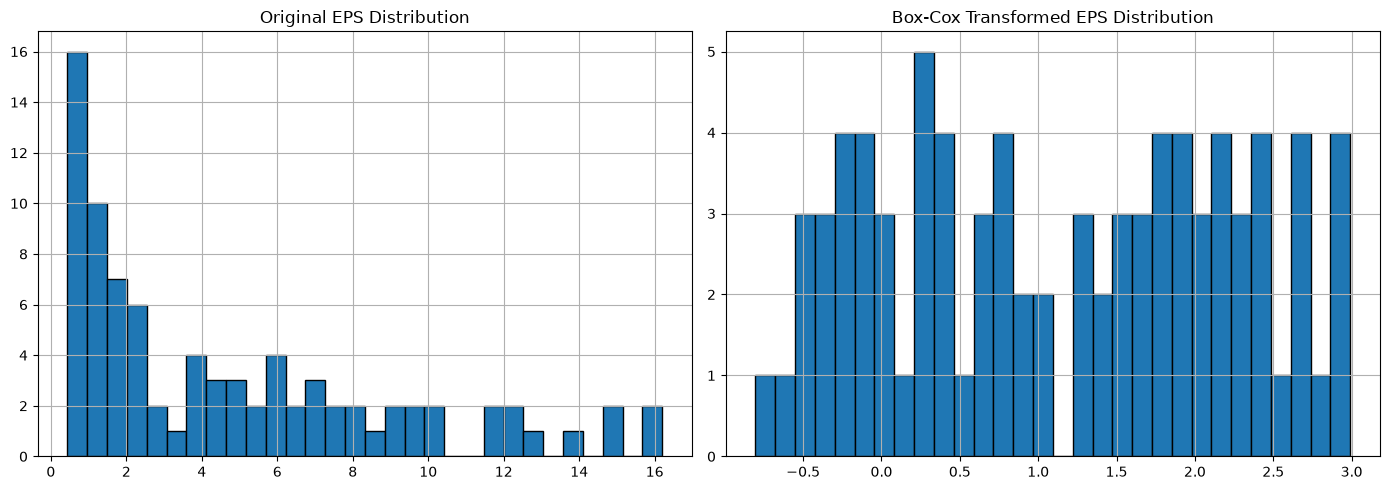

In [10]:
# Visualise Transformed Series and Compare Distributions

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df["JohnsonJohnson"].hist(ax=ax[0], bins=30, edgecolor='black')
ax[0].set_title("Original EPS Distribution")
xts.hist(ax=ax[1], bins=30, edgecolor='black')
ax[1].set_title("Box-Cox Transformed EPS Distribution")
plt.tight_layout()
plt.show()

We can double-check our visual conclusion about the distribution using a statistical test.

Here, we will apply a log transformation and use a statistical test (`normaltest`) to assess whether the transformed data is approximately normally distributed.

**This isn't required for time series models**, but it helps us understand whether the transformation improved the distribution.

A higher p-value (typically > 0.05) suggests that the data does not significantly differ from a normal distribution.

In [11]:
# Perform the normality test on the transformed series
stat, pvalue = normaltest(xts)

print(f"Normality test statistic: {stat:.4f}, p-value: {pvalue:.4f}")

# Interpret the results
if pvalue < 0.05:
    print("The transformed series is likely not normally distributed (reject H0).")
else:
    print("The transformed series appears approximately normally distributed (fail to reject H0).")

Normality test statistic: 40.5921, p-value: 0.0000
The transformed series is likely not normally distributed (reject H0).


>> **Note:** Box-Cox does not guarantee normality because it actually does not really check for normality; the method checks for the smallest standard deviation. In the plots above, the boxcox transformation did not really convert the dataseries into a normal distribution.

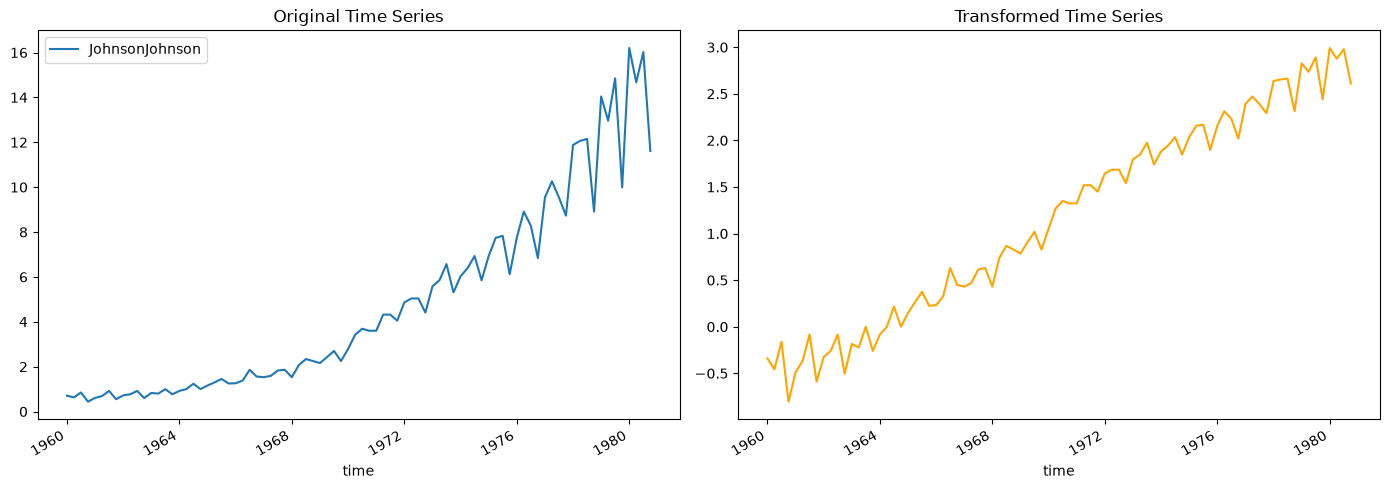

In [12]:
# Let us see what the dataset look like before and after the transformation
# there will be two plots

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Original Time Series
df.plot(ax=ax[0])

# Transformed Time Series
xts.plot(ax=ax[1], color='orange')

# Labels and Titles
ax[0].set_title("Original Time Series")
ax[1].set_title("Transformed Time Series")

plt.tight_layout()
plt.show()

As you can see from the plots above, the boxcox transformation looks a bit more stable than the original dataseries.

**Step 1.7 Explore Log transformation**

**Log transformation** is commonly used in data science and machine learning to reduce skewness and stablisise variance - especially when values grow exponentially or variance increases with the level of the data.

In time series analysis, log transformation is often applied before modelling to make the series more suitable for methods that assume constant variance.

In [14]:
# use log transform
log_transformed = np.log(df)
_, p = normaltest(log_transformed)

# removing the value from the dataframe so that we can format it
index = 0
pvalue = p[index]
print("significance: %.4f" % pvalue)

significance: 0.0000


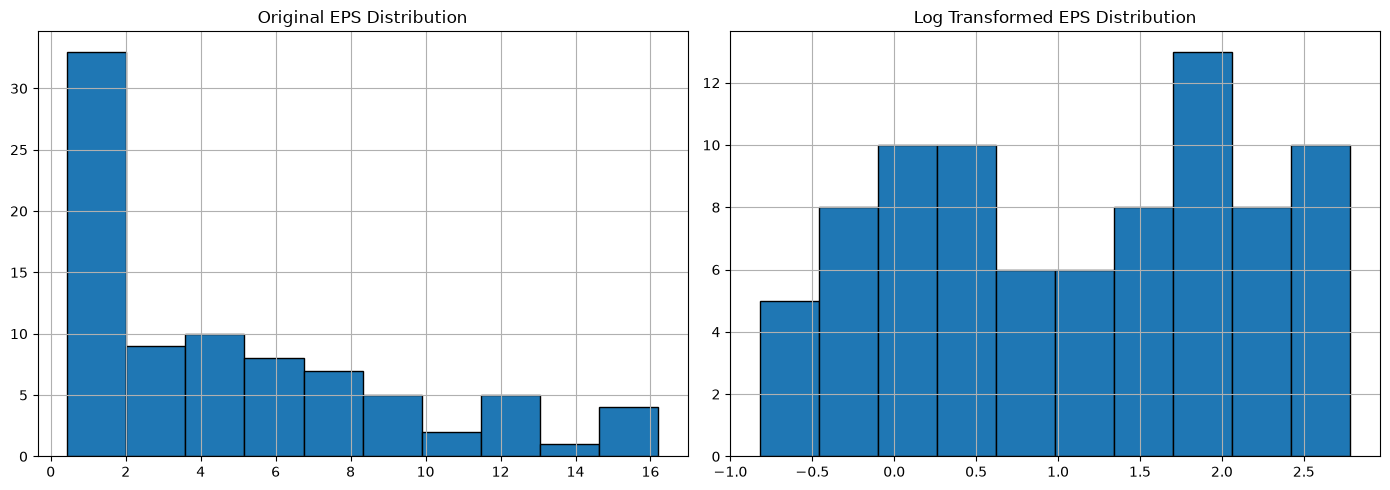

In [16]:
# Visualise Log Transformed Series and Compare Distributions

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df.hist(ax=ax[0], edgecolor='black')
ax[0].set_title("Original EPS Distribution")
log_transformed.hist(ax=ax[1], edgecolor='black')
ax[1].set_title("Log Transformed EPS Distribution")
plt.tight_layout()
plt.show()

**Conclusion**

The **Box-Cox transformation** has improved the **distribution of the data**, though it is still not fully **normal**. This is often the case in real-world **time series**.

At this point, the data is **not normally distributed - and that's usually fine**. In **time series forecasting, normality of the raw data is not a required assumption**. Instead, what matters more is:

- Whether the **residuals** from your model are approximately **normally distributed**

- Whether **variance is stable**

- Whether the residuals resemble **white noise** (uncorrelated, zero mean)

Further **data cleaning or preprocessing** may help on specific cases (e.g., outlier removal), but there is **no need to force the data to be normally distributed** unless the method you're using explicitly requires it (e.g., for some types of statistical inference).

>> **Takeaway: Normality is not essential for forecasting accuracy**. Focus on making sure your **model assumptions hold**, especially in the **residuals**, rather than trying to make the original data look perfectly normal.

#### Part 2 - Plotting time series data using pandas

You have already seen in the previous codes how to plot histograms and your data series.